# Thesis Experiment Design: AI-Gated Markowitz Validation
This notebook focuses on comparing the proposed AI-Gated Markowitz strategy against key theoretical and market benchmarks.

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import os
from scipy.optimize import minimize

# Ensure plots look nice
plt.style.use('ggplot')

In [9]:
# Load Multi-Asset Data
file_path = 'real_crypto_data.csv'
try:
    df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
    print("Loaded Assets:", df.columns.tolist())
except FileNotFoundError:
    print("File not found. Generating dummy.")
    dates = pd.date_range(start='2023-01-01', periods=1095)
    df = pd.DataFrame(np.random.randn(1095, 5), index=dates, columns=['BTC','ETH','XRP','LTC','BCH'])
    df = (1 + df.pct_change().fillna(0)).cumprod() * 100

def get_market_features(df):
    returns = df.pct_change().fillna(0)
    volatility = returns.rolling(window=20).std().fillna(0)
    sma50 = df.rolling(window=50).mean()
    momentum = (df / sma50 - 1).fillna(0)
    return returns, volatility, momentum

returns_df, vol_df, mom_df = get_market_features(df)
assets = df.columns.tolist()
n_assets = len(assets)

# Define Training Range (2023 and 2024)
train_mask = (df.index.year == 2023) | (df.index.year == 2024)
train_df_slice = df[train_mask]
train_returns_slice = returns_df[train_mask]
train_vol_slice = vol_df[train_mask]
train_mom_slice = mom_df[train_mask]

# Define Test Range (2025 Only)
test_mask = (df.index.year == 2025)
test_df_slice = df[test_mask]

print(f"Total Data Points: {len(df)}")
print(f"Training Data (2023-2024): {len(train_df_slice)} days")
print(f"Testing Data (2025): {len(test_df_slice)} days")

Loaded Assets: ['BCH', 'BTC', 'ETH', 'LTC', 'XRP']
Total Data Points: 1096
Training Data (2023-2024): 731 days
Testing Data (2025): 365 days


In [10]:
class MultiAssetCryptoEnv(gym.Env):
    def __init__(self, price_df, returns_df, vol_df, mom_df):
        super(MultiAssetCryptoEnv, self).__init__()
        self.price_df = price_df
        self.returns_df = returns_df
        self.vol_df = vol_df
        self.mom_df = mom_df
        self.assets = price_df.columns
        self.n_assets = len(self.assets)
        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.n_assets * 3,), dtype=np.float32)
        self.current_step = 0
        self.max_steps = len(price_df) - 1

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        r = self.returns_df.iloc[self.current_step].values
        v = self.vol_df.iloc[self.current_step].values
        m = self.mom_df.iloc[self.current_step].values
        return np.concatenate([r, v, m]).astype(np.float32)

    def step(self, action):
        weights = np.exp(action) / np.sum(np.exp(action))
        asset_weights = weights[:-1]
        cash_weight = weights[-1]
        
        if self.current_step >= self.max_steps:
            return self._get_obs(), 0, True, False, {}
            
        next_day_returns = self.returns_df.iloc[self.current_step + 1].values
        portfolio_return = np.sum(asset_weights * next_day_returns)
        reward = np.log(1 + portfolio_return)
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        info = {'return': portfolio_return, 'weights': asset_weights, 'cash': cash_weight}
        return self._get_obs(), reward, terminated, False, info

In [11]:
# 1. Load Standard PPO (Baseline) if exists, else init dummy
# We use this as a representative of "Pure RL" performance
model_path = "./best_model_ppo/best_model"
dummy_env = MultiAssetCryptoEnv(train_df_slice, train_returns_slice, train_vol_slice, train_mom_slice)
dummy_env = DummyVecEnv([lambda: dummy_env])

if os.path.exists(model_path + ".zip"):
    model_baseline = PPO.load(model_path)
    print("Loaded DeepRL PPO (Baseline).")
else:
    print("Baseline model not found! Training a fresh Baseline on 2023-2024 data...")
    model_baseline = PPO("MlpPolicy", dummy_env, verbose=0)
    model_baseline.learn(total_timesteps=10000)
    print("Fresh DeepRL PPO (Baseline) Training Complete.")

Baseline model not found! Training a fresh Baseline on 2023-2024 data...
Fresh DeepRL PPO (Baseline) Training Complete.


In [12]:
# --- AI-Gated Classifier Training (Random Forest) ---
# Training on 2023-2024 Data ONLY.
# Predicting on 2025 Data (Test Set).

print('Training AI Gatekeeper (Bull/Bear Classifier)...')
market_ret = returns_df.mean(axis=1)
feat = pd.DataFrame(index=returns_df.index)
feat['Vol_20'] = market_ret.rolling(20).std()
feat['Mom_20'] = market_ret.rolling(20).mean()
feat['Target'] = (market_ret.shift(-1) > 0).astype(int)
feat = feat.dropna()

X_rf = feat[['Vol_20', 'Mom_20']]
y_rf = feat['Target']

# Train Mask: 2023-2024
train_rf_mask = (feat.index.year == 2023) | (feat.index.year == 2024)
X_train_rf = X_rf[train_rf_mask]
y_train_rf = y_rf[train_rf_mask]

clf = RandomForestClassifier(n_estimators=100, min_samples_split=10, random_state=42)
clf.fit(X_train_rf, y_train_rf)

# Predict on ALL data (will filter by index in loop)
rf_probs_all = clf.predict_proba(X_rf)[:, 1]
rf_probs_series = pd.Series(rf_probs_all, index=X_rf.index)
print(f'AI Gatekeeper Trained. Train Acc: {accuracy_score(y_train_rf, clf.predict(X_train_rf)):.2f}')

# Helper for Markowitz
def optimize_markowitz(returns_window, cov_matrix):
    n = returns_window.shape[1]
    if n == 0: return []
    def neg_sharpe(weights):
        fed_return = np.sum(returns_window.mean() * weights) * 252
        fed_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
        return -(fed_return / fed_vol) if fed_vol > 0 else 0
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    try:
        res = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return res.x
    except:
        return init_guess

Training AI Gatekeeper (Bull/Bear Classifier)...
AI Gatekeeper Trained. Train Acc: 0.88


In [13]:
def run_thesis_evaluation(eval_df, eval_returns, eval_vol, eval_mom):
    print(f"\n{'='*10} Starting Thesis Experiment Evaluation (Year 2025) {'='*10}")
    if len(eval_df) < 10:
        return None

    env_eval = MultiAssetCryptoEnv(eval_df, eval_returns, eval_vol, eval_mom)
    obs, _ = env_eval.reset()

    # Selected Models for Thesis Narrative
    portfolio_values = {
        'AI-Gated Markowitz (Proposed)': [100.0],
        'Markowitz (Theory Baseline)': [100.0],
        'Trend-Based (Rule-Based)': [100.0],
        'DeepRL PPO (Deep Learning)': [100.0],
        'Buy and Hold (Market Baseline)': [100.0]
    }
    bnh_holdings = np.ones(n_assets) * (100.0 / n_assets) 
    lookback = 50

    for step in range(len(eval_df) - 1):
        current_date = eval_df.index[step]
        
        # 1. PPO Baseline (Deep Learning Representative)
        action_base, _ = model_baseline.predict(obs, deterministic=True)
        obs, reward, done, _, info = env_eval.step(action_base)
        ret_base = info['return']
        portfolio_values['DeepRL PPO (Deep Learning)'].append(portfolio_values['DeepRL PPO (Deep Learning)'][-1] * (1 + ret_base))
        
        # Prepare Market Data
        if step + 1 < len(eval_returns):
            day_returns = eval_returns.iloc[step + 1].values
        else:
            day_returns = np.zeros(n_assets)

        # 2. Markowitz (Theory Baseline) & Base for others
        glob_idx = returns_df.index.get_loc(current_date)
        if glob_idx >= lookback:
            window_ret = returns_df.iloc[glob_idx-lookback:glob_idx]
            cov_mat = window_ret.cov().values
            mw_weights = optimize_markowitz(window_ret, cov_mat)
        else:
            mw_weights = np.ones(n_assets) / n_assets
        
        ret_mw = np.sum(mw_weights * day_returns)
        portfolio_values['Markowitz (Theory Baseline)'].append(portfolio_values['Markowitz (Theory Baseline)'][-1] * (1 + ret_mw))

        # 3. AI-Gated Markowitz (Proposed)
        if current_date in rf_probs_series.index:
            bull_prob = rf_probs_series.loc[current_date]
            if bull_prob > 0.52: ai_mw_w = mw_weights
            elif bull_prob < 0.48: ai_mw_w = 0.0 # Bear -> Cash
            else: ai_mw_w = 0.5 * mw_weights
        else:
            ai_mw_w = 0.5 * mw_weights
        ret_ai = np.sum(ai_mw_w * day_returns)
        portfolio_values['AI-Gated Markowitz (Proposed)'].append(portfolio_values['AI-Gated Markowitz (Proposed)'][-1] * (1 + ret_ai))

        # 4. Trend-Based (Rule-Based Baseline)
        current_mom = np.mean(eval_mom.iloc[step].values)
        if current_mom > 0: trend_weights = mw_weights
        else: trend_weights = 0.5 * mw_weights # Defensive
        ret_trend = np.sum(trend_weights * day_returns)
        portfolio_values['Trend-Based (Rule-Based)'].append(portfolio_values['Trend-Based (Rule-Based)'][-1] * (1 + ret_trend))
        
        # 5. Buy and Hold (Market Baseline)
        bnh_holdings = bnh_holdings * (1 + day_returns)
        portfolio_values['Buy and Hold (Market Baseline)'].append(np.sum(bnh_holdings))
        
    return portfolio_values


========== Starting Thesis Experiment Evaluation (Year 2025) ==========

>>> FINAL THESIS EXPERIMENT RESULTS (2025) <<<
                               Total Return Volatility Sharpe Ratio
AI-Gated Markowitz (Proposed)        90.93%     62.20%         1.35
Markowitz (Theory Baseline)          20.74%     72.86%         0.62
Trend-Based (Rule-Based)             18.30%     50.20%         0.58
DeepRL PPO (Deep Learning)            2.77%     49.55%         0.30
Buy and Hold (Market Baseline)       -6.61%     60.18%         0.19


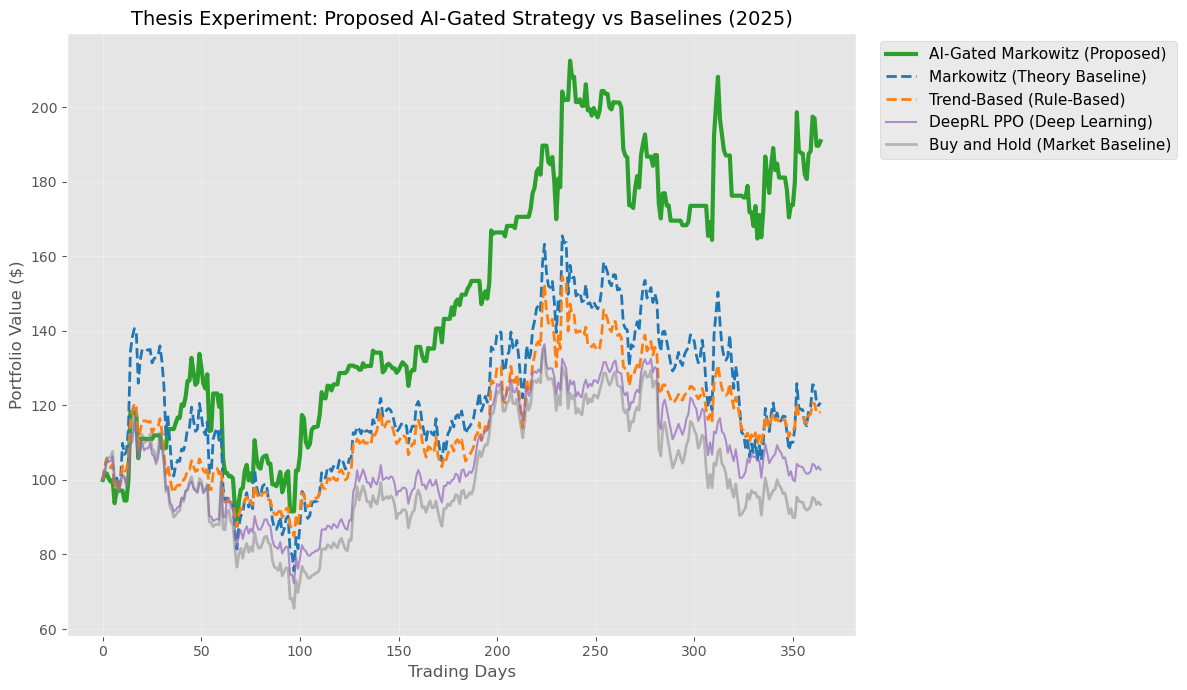

In [14]:
# Evaluate on 2025
test_mask = (df.index.year == 2025)
df_2025 = df[test_mask]
ret_2025 = returns_df[test_mask]
vol_2025 = vol_df[test_mask]
mom_2025 = mom_df[test_mask]

results = run_thesis_evaluation(df_2025, ret_2025, vol_2025, mom_2025)

# Metrics
metric_cols = ['Total Return', 'Volatility', 'Sharpe Ratio']
def calculate_metrics(p_values_dict):
    metrics = {}
    for name, values in p_values_dict.items():
        arr = np.array(values)
        if len(arr) < 2: continue
        rets = arr[1:] / arr[:-1] - 1
        if len(rets) == 0: continue
        
        total_ret = (arr[-1] / arr[0]) - 1
        vol = np.std(rets) * np.sqrt(365)
        if np.std(rets) > 1e-6:
            sharpe = (np.mean(rets) / np.std(rets)) * np.sqrt(365)
        else:
            sharpe = 0.0
        metrics[name] = [total_ret, vol, sharpe]
    return pd.DataFrame(metrics, index=metric_cols).T

if results:
    print(f"\n>>> FINAL THESIS EXPERIMENT RESULTS (2025) <<<")
    df_metrics = calculate_metrics(results)
    
    # Sorting for better presentation (Proposed first)
    # We want Proposed at top, then benchmarks
    priority = ['AI-Gated Markowitz (Proposed)', 'Markowitz (Theory Baseline)', 
                'Trend-Based (Rule-Based)', 'DeepRL PPO (Deep Learning)', 'Buy and Hold (Market Baseline)']
    df_metrics = df_metrics.reindex(priority)

    df_fmt = df_metrics.copy()
    for c in ['Total Return', 'Volatility']:
        df_fmt[c] = df_fmt[c].apply(lambda x: f"{x:.2%}")
    df_fmt['Sharpe Ratio'] = df_fmt['Sharpe Ratio'].apply(lambda x: f"{x:.2f}")
    
    print(df_fmt)
    
    # Visualization
    plt.figure(figsize=(12, 7))
    styles = {
        'AI-Gated Markowitz (Proposed)': {'color': '#2ca02c', 'linewidth': 3}, # Green, Bold
        'Markowitz (Theory Baseline)': {'color': '#1f77b4', 'linewidth': 2, 'linestyle': '--'}, # Blue dashed
        'Trend-Based (Rule-Based)': {'color': '#ff7f0e', 'linewidth': 2, 'linestyle': '--'}, # Orange dashed
        'DeepRL PPO (Deep Learning)': {'color': '#9467bd', 'linewidth': 1.5, 'alpha': 0.7}, # Purple
        'Buy and Hold (Market Baseline)': {'color': 'gray', 'linewidth': 2, 'alpha': 0.5} # Gray
    }
    
    for name, values in results.items():
         style = styles.get(name, {})
         plt.plot(values, label=name, **style)
         
    plt.title("Thesis Experiment: Proposed AI-Gated Strategy vs Baselines (2025)", fontsize=14)
    plt.ylabel("Portfolio Value ($)")
    plt.xlabel("Trading Days")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()